## Reddit Hyperlink Network Dataset

The hyperlink network represents the directed connections between two subreddits (a subreddit is a community on Reddit). We also provide subreddit embeddings. The network is extracted from publicly available Reddit data of 2.5 years from Jan 2014 to April 2017.

Subreddit Hyperlink Network: the subreddit-to-subreddit hyperlink network is extracted from the posts that create hyperlinks from one subreddit to another. We say a hyperlink originates from a post in the source community and links to a post in the target community. Each hyperlink is annotated with three properties: the timestamp, the sentiment of the source community post towards the target community post, and the text property vector of the source post. The network is directed, signed, temporal, and attributed.

Note that each post has a title and a body. The hyperlink can be present in either the title of the post or in the body. Therefore, we provide one network file for each.

The dataset is distributed as CSV file available on http://snap.stanford.edu/data/soc-RedditHyperlinks.html.

The notebook uses `soc-redditHyperlinks-body.tsv` -- Network of subreddit-to-subreddit hyperlinks extracted from hyperlinks in the body of the post.

The file contains:

 * `SOURCE_SUBREDDIT`: the subreddit where the link originates
 * `TARGET_SUBREDDIT`: the subreddit where the link ends
 * `POST_ID`: the post in the source subreddit that starts the link
 * `TIMESTAMP`: time time of the post
 * `LINK_SENTIMENT`: label indicating if the source post is explicitly negative towards the target post. The value is -1 if the source is negative towards the target, and 1 if it is neutral or positive. The label is created using crowd-sourcing and training a text based classifier, and is better than simple sentiment analysis of the posts. Please see the reference paper for details.
 * `POST_PROPERTIES`: a vector representing the text properties of the source post, listed as a list of comma separated numbers. (See the website for the complete list of properties)


# Homework - Network of Negativity

Identify the network of negativity. The dataset also contain attribute `LINK_SENTIMENT` which idetifies whether the the sentiment of the reference (post) is positive or neutral (+1) or negative (-1). Create a subgraph with only the negative links and analyse the graph. Find:

1) The two subreddits which are the most likely to express negative view on each other.
2) Find the "hubs of negativity" - the subreddits with highest betweeness, pagerank, ... centrality and describe what they mean for the network.
3) Identify positive subreddits - ones, that never get or give negative sentiment link.
4) Find cliques of negativity (subsets of subreddits that have negative links between each other).

The preffered submission is Jupyter notebook with all above questions answered, commented and supported by visualisation. Submit your notebook into GITLAB.


# 0. Create a subgraph with only the negative links

In [1]:
import pandas as pd
import networkx as nx

In [2]:
# Read the dataset
df = pd.read_csv("soc-redditHyperlinks-body.tsv", sep="\t")

# Keep only negative links
df_neg = df[df["LINK_SENTIMENT"] == -1]

# Build a directed multigraph from only negative edges
negative_graph = nx.MultiDiGraph()

for _, row in df_neg.iterrows():
    negative_graph.add_edge(
        row["SOURCE_SUBREDDIT"],
        row["TARGET_SUBREDDIT"],
        POST_ID=row["POST_ID"],
        TIMESTAMP=row["TIMESTAMP"],
        LINK_SENTIMENT=row["LINK_SENTIMENT"]
    )

print("DONE")
print("Number of nodes:", negative_graph.number_of_nodes())
print("Number of edges:", negative_graph.number_of_edges())

DONE
Number of nodes: 6370
Number of edges: 21070


In [3]:
# Check
for i, (u, v, data) in enumerate(negative_graph.edges(data=True)):
    print(u, "->", v, "| sentiment:", data.get("LINK_SENTIMENT"))
    if i == 9:
        break

theredlion -> soccer | sentiment: -1
theredlion -> offmychest | sentiment: -1
theredlion -> outoftheloop | sentiment: -1
theredlion -> scotland | sentiment: -1
soccer -> science | sentiment: -1
karmaconspiracy -> funny | sentiment: -1
karmaconspiracy -> funny | sentiment: -1
karmaconspiracy -> funny | sentiment: -1
karmaconspiracy -> aww | sentiment: -1
karmaconspiracy -> movies | sentiment: -1


# 1. The two subreddits which are the most likely to express negative view on each other.

In [4]:
from collections import Counter

In [5]:
# Count how many negative edges exist for each directed pair
directed_counts = Counter()

for u, v in negative_graph.edges():
    directed_counts[(u, v)] += 1

best_pair = None
best_score = -1
best_ab = 0
best_ba = 0

visited = set()

for (a, b), count_ab in directed_counts.items():
    if (a, b) in visited or (b, a) in visited:
        continue

    count_ba = directed_counts.get((b, a), 0)

    # We only care about mutual negativity
    if count_ab > 0 and count_ba > 0:
        score = count_ab + count_ba

        if score > best_score:
            best_score = score
            best_pair = (a, b)
            best_ab = count_ab
            best_ba = count_ba

    visited.add((a, b))
    visited.add((b, a))

if best_pair is not None:
    a, b = best_pair
    print("Most mutually negative pair:")
    print(f"{a} <-> {b}")
    print(f"{a} -> {b}: {best_ab} negative links")
    print(f"{b} -> {a}: {best_ba} negative links")
    print(f"Total mutual negative links: {best_score}")
else:
    print("No pair with mutual negative links was found.")

Most mutually negative pair:
askreddit <-> writingprompts
askreddit -> writingprompts: 2 negative links
writingprompts -> askreddit: 56 negative links
Total mutual negative links: 58


In [6]:
from pyvis.network import Network
from collections import Counter
import matplotlib
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# count directed edges
directed_counts = Counter()
for u, v in negative_graph.edges():
    directed_counts[(u, v)] += 1

# build mutual graph with score
mutual_edges = []
visited = set()

for (a, b), count_ab in directed_counts.items():
    if (a, b) in visited or (b, a) in visited:
        continue

    count_ba = directed_counts.get((b, a), 0)

    if count_ab > 0 and count_ba > 0:
        score = count_ab + count_ba
        mutual_edges.append((a, b, score))

    visited.add((a, b))
    visited.add((b, a))

# take top edges (important!)
mutual_edges = sorted(mutual_edges, key=lambda x: x[2], reverse=True)[:20]

# normalize scores for colors
scores = [s for _, _, s in mutual_edges]
norm = mcolors.Normalize(vmin=min(scores), vmax=max(scores))
cmap = matplotlib.colormaps.get_cmap('plasma')

def score_to_color(score):
    rgba = cmap(norm(score))
    return mcolors.to_hex(rgba)

# create pyvis graph
net = Network(notebook=True, cdn_resources='remote')
nodes = set()
for u, v, _ in mutual_edges:
    nodes.add(u)
    nodes.add(v)

for node in nodes:
    net.add_node(node, label=node)

# add edges with color
for u, v, score in mutual_edges:
    color = score_to_color(score)
    net.add_edge(u, v, value=score, color=color, title=f"score={score}")

from IPython.display import HTML
net.save_graph("mutual_negativity_graph.html")
HTML("mutual_negativity_graph.html")

## Method
To identify the pair of subreddits most likely to express negative views on each other, I defined the following score for each pair \((A,B)\):

\[
S(A,B) = N(A,B) + N(B,A)
\]

where \(N(A,B)\) is the number of negative links from subreddit \(A\) to subreddit \(B\).

This score measures the total amount of mutual negative interactions between the two subreddits. A higher value of \(S(A,B)\) indicates that both subreddits frequently express negative views toward each other, and is therefore interpreted as a higher likelihood of mutual negativity.

To support the analysis, I visualized the resulting graph using an interactive network representation (the 20 strongest negative interactions). Edge colors were mapped to the mutual negativity score \(S(A,B)\), allowing stronger negative interactions to be easily identified.

## Discussion

The pair with the highest mutual negativity score is *askreddit* and *writingprompts*, with a total of 58 negative interactions.

However, the interaction is highly asymmetric: while there are 56 negative links from *writingprompts* to *askreddit*, there are only 2 in the opposite direction. This suggests that the negative relationship is largely one-sided.

This result highlights a limitation of the chosen scoring method. Since the score is based on the sum \(S(A,B) = N(A,B) + N(B,A)\), it favors pairs with a high total number of negative interactions, even if the negativity is not balanced between the two subreddits.

The visualization further supports this result, as the edge between *askreddit* and *writingprompts* stands out due to its high score.

# 2. Find the "hubs of negativity" - the subreddits with highest betweeness, pagerank, ... centrality and describe what they mean for the network.

In [7]:
# Convert MultiDiGraph to a weighted DiGraph
# Multiple edges between the same nodes are aggregated into a single edge with a weight
G = nx.DiGraph()

for u, v, data in negative_graph.edges(data=True):
    if G.has_edge(u, v):
        G[u][v]['weight'] += 1
    else:
        G.add_edge(u, v, weight=1)

print("Graph ready:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")


# ---------------------------
# PageRank centrality
# ---------------------------
pagerank = nx.pagerank(G, weight='weight')

top_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 nodes by PageRank:")
for node, score in top_pagerank:
    print(node, score)


# ---------------------------
# Betweenness centrality
# ---------------------------
betweenness = nx.betweenness_centrality(G, weight='weight')

top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 nodes by Betweenness Centrality:")
for node, score in top_betweenness:
    print(node, score)


# ---------------------------
# In-degree centrality (who receives negativity)
# ---------------------------
in_degree = dict(G.in_degree(weight='weight'))

top_in_degree = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 nodes by In-Degree (receiving negativity):")
for node, score in top_in_degree:
    print(node, score)


# ---------------------------
# Out-degree centrality (who sends negativity)
# ---------------------------
out_degree = dict(G.out_degree(weight='weight'))

top_out_degree = sorted(out_degree.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 nodes by Out-Degree (sending negativity):")
for node, score in top_out_degree:
    print(node, score)

Graph ready: 6370 nodes, 14513 edges

Top 10 nodes by PageRank:
askreddit 0.02504509572855618
worldnews 0.008947460885968173
videos 0.008464888864227057
todayilearned 0.007716103156498439
iama 0.0073149052098655494
pics 0.007114238446581011
funny 0.00688329336934544
news 0.006728197236794868
relationships 0.006184869715635638
ukraine 0.0058822888760017645

Top 10 nodes by Betweenness Centrality:
subredditdrama 0.0658967944938671
askreddit 0.05257072395015882
self 0.021736264720640115
drama 0.02077816465802163
the_donald 0.01596199391185766
leagueoflegends 0.014532832928789676
conspiracy 0.014370985572206419
legaladvice 0.014190641846448419
writingprompts 0.013223215877648312
offmychest 0.01210418312295069

Top 10 nodes by In-Degree (receiving negativity):
askreddit 892
worldnews 390
news 390
videos 373
pics 364
todayilearned 362
funny 304
adviceanimals 235
relationships 216
kotakuinaction 200

Top 10 nodes by Out-Degree (sending negativity):
subredditdrama 1437
circlebroke 702
drama 51

In [8]:
from pyvis.network import Network
import matplotlib
import matplotlib.colors as mcolors

# normalize pagerank values
values = list(pagerank.values())
norm = mcolors.Normalize(vmin=min(values), vmax=max(values))

cmap = matplotlib.colormaps.get_cmap('viridis')

def pr_to_color(value):
    rgba = cmap(norm(value))
    return mcolors.to_hex(rgba)

# create pyvis graph
net = Network(notebook=True, cdn_resources='remote')

# OPTIONAL: take only top nodes for clarity
top_nodes = [node for node, _ in sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:30]]

subgraph = G.subgraph(top_nodes)

# add nodes
for node in subgraph.nodes():
    pr = pagerank[node]
    net.add_node(
        node,
        label=node,
        size=10 + pr * 5000,   # scale node size
        color=pr_to_color(pr),
        title=f"PageRank: {pr:.5f}"
    )

# add edges
for u, v, data in subgraph.edges(data=True):
    net.add_edge(u, v, value=data['weight'])

# physics for nicer layout
net.force_atlas_2based()

# save and show
net.save_graph("pagerank_graph.html")

from IPython.display import HTML
HTML("pagerank_graph.html")

## Method

To identify the hubs of negativity in the network, I analyzed the negative interaction graph using several centrality measures.

First, I constructed a directed weighted graph in which edges represent negative interactions, and edge weights correspond to the number of negative links between subreddits.

I then computed the following centrality measures:

- **PageRank**, to identify subreddits that are globally important in the network of negative interactions.
- **Betweenness centrality**, to detect subreddits that act as intermediaries or bridges between different parts of the network.
- **In-degree centrality (weighted)**, to identify subreddits that receive a high volume of negative interactions.
- **Out-degree centrality (weighted)**, to identify subreddits that generate a high volume of negative interactions.

For each measure, I ranked the nodes and selected the top subreddits as the main hubs of negativity.

To support the analysis, I also visualized the network using PageRank scores, mapping node size and color to their centrality values. This provides an intuitive representation of the most influential subreddits in the network.

## Discussion

The centrality analysis reveals several types of “hubs of negativity” in the network, each capturing a different role.

Subreddits such as *askreddit*, *worldnews*, and *videos* rank highest in PageRank and in-degree centrality, indicating that they receive a large volume of negative interactions and are globally important targets in the network. These are large, general-purpose communities, suggesting that highly visible subreddits tend to attract more negative attention.

In contrast, subreddits like *subredditdrama*, *circlebroke*, and *drama* dominate the out-degree centrality ranking. This indicates that they are major sources of negative interactions, actively linking to and criticizing other communities.

Betweenness centrality highlights a different role. Subreddits such as *subredditdrama*, *self*, and *legaladvice* act as bridges between different parts of the network, suggesting that they connect otherwise separate communities through negative interactions. This indicates that negativity is not only concentrated within communities, but also propagates between them through specific intermediaries.

Overall, the results suggest a structured network in which negativity is not evenly distributed: some subreddits primarily receive it, others primarily generate it, and a third group plays a key role in spreading it across the network.

These findings are consistent with the results from the previous analysis. For example, the pair (*askreddit*, *writingprompts*) showed strong mutual negativity, and both subreddits also appear in the centrality rankings—*askreddit* as a major receiver of negativity and *writingprompts* as a significant source. This further supports the interpretation that interactions between central hubs can dominate the overall structure of negative relationships in the network.

The visualization reinforces these findings, with *askreddit* clearly emerging as the most dominant node due to its high PageRank.

# 3. Identify positive subreddits - ones, that never get or give negative sentiment link.

In [9]:
# Get all subreddits from the full dataset
all_nodes = set(df["SOURCE_SUBREDDIT"]).union(set(df["TARGET_SUBREDDIT"]))

# Get all subreddits that appear in negative interactions
negative_nodes = set(negative_graph.nodes())

# Identify positive subreddits (never involved in negative edges)
positive_subreddits = all_nodes - negative_nodes

# ---------------------------
# Print counts
# ---------------------------
print("Total number of subreddits:", len(all_nodes))
print("Number of subreddits with negative interactions:", len(negative_nodes))
print("Number of positive subreddits (no negative interactions):", len(positive_subreddits))

# ---------------------------
# Print examples
# ---------------------------
print("\nSome positive subreddits:")
print(list(positive_subreddits)[:20])

Total number of subreddits: 35776
Number of subreddits with negative interactions: 6370
Number of positive subreddits (no negative interactions): 29406

Some positive subreddits:
['commanderholly', 'zombicide', 'nazdestwi', 'kancolle', 'tinycode', 'labourcirclejerk', 'highstakesteslamotors', 'imaginaryrobotics', 'dcsstourney', 'punjabi', 'quakecon', '1098thworldproblems', 'mizzou', 'amazonspecials', 'mildlyreposting', 'the_hofer', 'pufflehugs04', 'throatpies', 'straightedge', 'phxpokemongo']


In [12]:
import random

# Build the full directed graph from the complete dataset
full_graph = nx.DiGraph()

for _, row in df.iterrows():
    full_graph.add_edge(row["SOURCE_SUBREDDIT"], row["TARGET_SUBREDDIT"])

# Sets of nodes
all_nodes = set(full_graph.nodes())
negative_nodes = set(negative_graph.nodes())
positive_subreddits = all_nodes - negative_nodes

# Sample nodes for visualization
positive_sample = random.sample(list(positive_subreddits), min(20, len(positive_subreddits)))
negative_sample = random.sample(list(negative_nodes), min(20, len(negative_nodes)))

sample_nodes = positive_sample + negative_sample

# Create a subgraph from the sampled nodes
subgraph = full_graph.subgraph(sample_nodes).copy()

# Create pyvis network
net_q3 = Network(notebook=True, directed=True, cdn_resources='remote')

# Add nodes with colors according to negativity involvement
for node in subgraph.nodes():
    if node in positive_subreddits:
        color = "green"
        title = f"{node}<br>Status: positive subreddit"
    else:
        color = "red"
        title = f"{node}<br>Status: involved in negative interaction"

    net_q3.add_node(
        node,
        label=node,
        color=color,
        title=title
    )

# Add edges
for u, v in subgraph.edges():
    net_q3.add_edge(u, v)

# Improve layout
net_q3.force_atlas_2based()

# Save and display
net_q3.save_graph("question3_positive_subreddits.html")
HTML(filename="question3_positive_subreddits.html")

## Method

To identify positive subreddits, I considered subreddits that are not involved in any negative interactions, either as a source or as a target.

I first extracted the set of all subreddits appearing in the dataset, based on both source and target columns. Then, I constructed a graph containing only negative interactions and extracted the set of nodes participating in these interactions. Positive subreddits were defined as those that do not appear in the negative interaction graph, i.e., subreddits with zero in-degree and zero out-degree in the negative graph.

To illustrate the results, I generated a visualization of a sampled subgraph, where nodes were colored according to their involvement in negative interactions (green for positive subreddits and red for subreddits involved in negative links).

## Discussion

The results show that out of 35,776 subreddits in the dataset, only 6,370 are involved in negative interactions, while the majority (29,406) are not associated with any negative links.

This suggests that negative interactions are concentrated within a relatively small subset of the network, rather than being uniformly distributed across all subreddits.

This observation is consistent with the findings from the previous analyses, where only a limited number of subreddits emerged as central hubs of negativity. Together, these results indicate that negative interactions tend to cluster around specific communities, while a large portion of the network remains unaffected.

# 4. Find cliques of negativity (subsets of subreddits that have negative links between each other).

In [13]:
# Build undirected graph from negative edges
G_undirected = nx.Graph()

for u, v in negative_graph.edges():
    G_undirected.add_edge(u, v)

# Find cliques
cliques = list(nx.find_cliques(G_undirected))

# Filter cliques of size >= 3
large_cliques = [c for c in cliques if len(c) >= 3]

# Sort by size
large_cliques = sorted(large_cliques, key=len, reverse=True)

# Print top cliques
print("Top cliques (size >= 3):")
for clique in large_cliques[:10]:
    print(f"Size {len(clique)}:", clique)

Top cliques (size >= 3):
Size 11: ['subredditdrama', 'drama', 'askreddit', 'copypasta', 'bestofoutrageculture', 'conspiracy', 'undelete', 'the_donald', 'iama', 'news', 'politics']
Size 11: ['subredditdrama', 'drama', 'askreddit', 'copypasta', 'circlebroke', 'conspiracy', 'the_donald', 'iama', 'undelete', 'news', 'politics']
Size 11: ['subredditdrama', 'drama', 'askreddit', 'circlejerkcopypasta', 'bestofoutrageculture', 'undelete', 'conspiracy', 'iama', 'the_donald', 'news', 'politics']
Size 11: ['subredditdrama', 'drama', 'askreddit', 'circlejerkcopypasta', 'circlebroke', 'the_donald', 'iama', 'conspiracy', 'undelete', 'news', 'politics']
Size 10: ['suicidewatch', 'offmychest', 'askreddit', 'depression', 'relationships', 'raisedbynarcissists', 'self', 'legaladvice', 'relationship_advice', 'advice']
Size 10: ['subredditdrama', 'drama', 'oppression', 'subredditcancer', 'conspiracy', 'circlebroke', 'shitredditsays', 'worldnews', 'india', 'badhistory']
Size 10: ['subredditdrama', 'drama', 

In [15]:
import networkx as nx
from collections import Counter

# Count directed negative edges
directed_counts = Counter()

for u, v in negative_graph.edges():
    directed_counts[(u, v)] += 1

# Build undirected graph with only mutual edges
G_mutual = nx.Graph()

visited = set()

for (a, b), count_ab in directed_counts.items():
    if (a, b) in visited or (b, a) in visited:
        continue

    count_ba = directed_counts.get((b, a), 0)

    # Keep only mutual negativity
    if count_ab > 0 and count_ba > 0:
        G_mutual.add_edge(a, b)

    visited.add((a, b))
    visited.add((b, a))

cliques = list(nx.find_cliques(G_mutual))

# Only cliques of size >= 3
large_cliques = [c for c in cliques if len(c) >= 3]

# Sort by size
large_cliques = sorted(large_cliques, key=len, reverse=True)

# Print top results
print("Top mutual negativity cliques:")
for clique in large_cliques[:10]:
    print(f"Size {len(clique)}:", clique)

Top mutual negativity cliques:
Size 4: ['askreddit', 'offmychest', 'sex', 'relationships']
Size 4: ['suicidewatch', 'relationships', 'offmychest', 'depression']
Size 4: ['the_donald', 'subredditcancer', 'undelete', 'conspiracy']
Size 4: ['the_donald', 'subredditcancer', 'drama', 'conspiracy']
Size 4: ['the_donald', 'subredditcancer', 'drama', 'againsthatesubreddits']
Size 4: ['subredditdrama', 'undelete', 'subredditcancer', 'conspiracy']
Size 4: ['subredditdrama', 'drama', 'gamerghazi', 'bestofoutrageculture']
Size 4: ['subredditdrama', 'drama', 'gamerghazi', 'againsthatesubreddits']
Size 4: ['subredditdrama', 'drama', 'subredditcancer', 'conspiracy']
Size 4: ['subredditdrama', 'drama', 'subredditcancer', 'againsthatesubreddits']


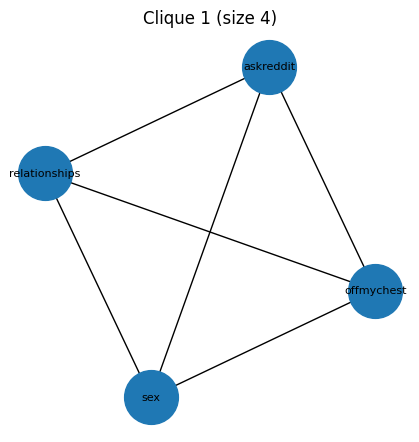

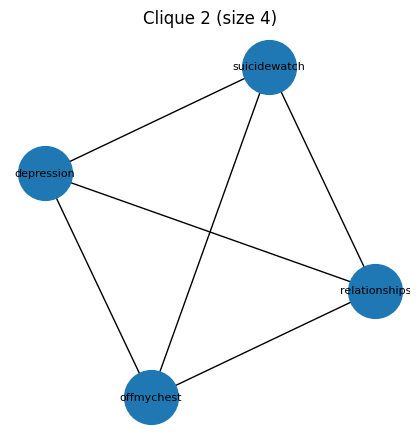

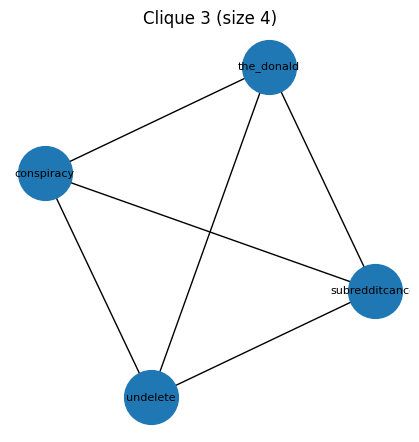

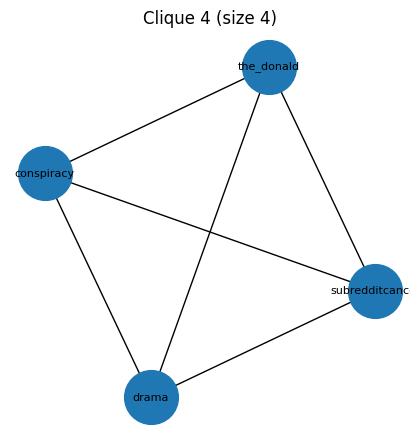

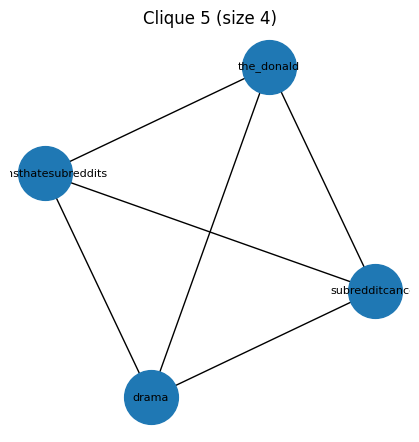

In [17]:
import matplotlib.pyplot as plt

# Take top 5 cliques for visualization
top_cliques = large_cliques[:5]

for i, clique in enumerate(top_cliques):
    G_clique = nx.Graph()

    # Add nodes
    G_clique.add_nodes_from(clique)

    # Fully connect the clique (since by definition it's complete)
    for u in clique:
        for v in clique:
            if u != v:
                G_clique.add_edge(u, v)

    # Draw
    plt.figure(figsize=(4, 4))
    pos = nx.spring_layout(G_clique, seed=42)

    nx.draw(
        G_clique,
        pos,
        with_labels=True,
        node_size=1500,
        font_size=8
    )

    plt.title(f"Clique {i+1} (size {len(clique)})")
    plt.axis('off')
    plt.show()

## Method

To identify cliques of negativity, I focused on **mutual negative interactions** between subreddits.  
I first constructed a directed negative interaction graph, and then created an undirected graph containing an edge between two subreddits only if both directed negative links existed between them.

I then applied clique detection on this undirected mutual-negativity graph. In this setting, a clique represents a subset of subreddits in which every pair has reciprocal negative interactions.

## Discussion

The largest cliques found in the mutual-negativity graph were of size 4. These cliques represent tightly connected groups of subreddits that exchange negative interactions with each other in a fully reciprocal way.

Some of the detected cliques appear to group communities around related topics or recurring conflicts. For example, cliques such as *askreddit*, *offmychest*, *sex*, and *relationships*, or *suicidewatch*, *relationships*, *offmychest*, and *depression*, suggest clusters of emotionally related or discussion-based communities with mutual tension. Other cliques involving *the_donald*, *subredditcancer*, *drama*, *conspiracy*, and *againsthatesubreddits* point to more explicitly controversial or conflict-driven parts of the network.

Using only reciprocal negative links makes this analysis stricter than a standard clique search, since it requires negativity to be mutual rather than one-sided.

Overall, the results suggest that negativity in the network is not only centered around individual hubs, but can also organize into small densely connected groups of mutually hostile subreddits.